# Day 09：训练的秘诀 —— Transformer 的工程技巧> 🚀 第十二周 · 注意力时代 · 第 9 天Transformer 的架构很优雅，但训练它并不容易。原始论文中有很多工程技巧，让训练从"不稳定"变成"可行"。今天，我们要学习这些关键的训练技巧。**今天的任务**：1. 学习学习率预热（Warmup）2. 学习标签平滑（Label Smoothing）3. 理解残差连接的深度影响---

## 1. 历史剧场：训练 Transformer 的"黑魔法"2017 年的 Transformer 论文中，Vaswani 等人花了很多篇幅描述训练细节：> "我们使用了 Adam 优化器，学习率在 warmup 阶段线性增长，之后按步数的倒数平方根衰减。"这些"黑魔法"在当时看起来很随意，但后来被证明是训练 Transformer 的关键。---

## 2. 生活隐喻：开车上高速- **没有 Warmup**：一上车就踩油门到底——容易失控（梯度爆炸）- **有 Warmup**：先慢慢加速，等稳定了再提速——安全又高效---

<p align="center">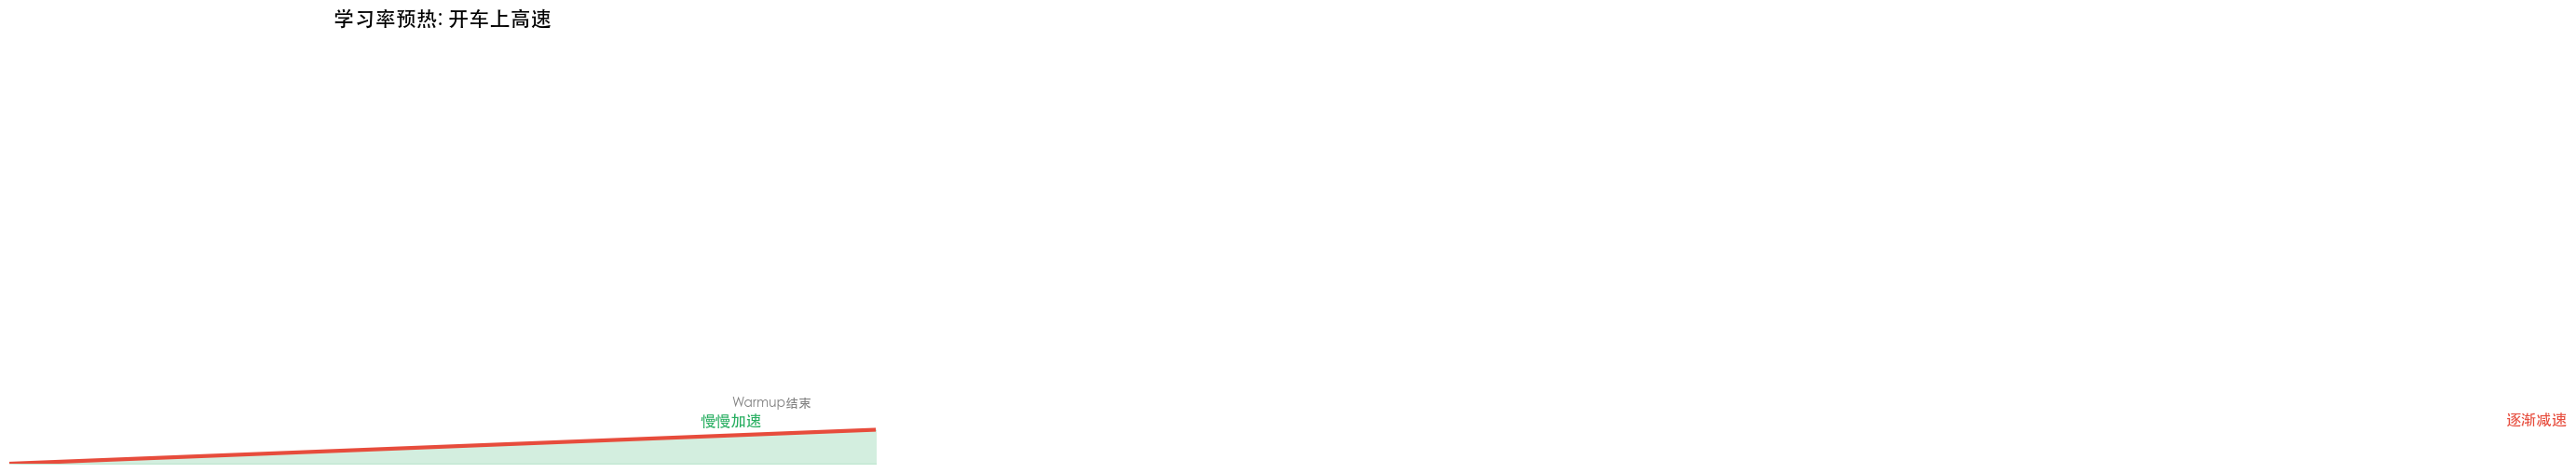</p>*学习率预热示意图*

## 3. 数学直觉：三个关键技巧### 3.1 学习率预热（Warmup + Decay）$$lr = d_{model}^{-0.5} \cdot \min(step^{-0.5}, step \cdot warmup^{-1.5})$$- **Warmup 阶段**（step < warmup_steps）：学习率线性增长- **Decay 阶段**（step > warmup_steps）：学习率按 $step^{-0.5}$ 衰减为什么需要 Warmup？- 训练初期，模型参数随机，大的学习率容易导致不稳定- Warmup 让模型在"热身"阶段用小学习率找到大致方向- 然后再用大学习率快速收敛### 3.2 标签平滑（Label Smoothing）普通标签：$y = [0, 0, 1, 0, 0]$（one-hot）平滑标签：$y = [0.02, 0.02, 0.92, 0.02, 0.02]$（$\epsilon = 0.1$）$$y_i^{smooth} = (1 - \epsilon) \cdot y_i + \epsilon / K$$为什么需要标签平滑？- 防止模型过于自信（overconfident）- 提高泛化能力- 改善校准（calibration）### 3.3 残差连接的深度影响Transformer 每层都有残差连接：$$x_{out} = x_{in} + \text{SubLayer}(x_{in})$$这和 ResNet 的思想一样：即使子层没学好（输出接近零），信息也能通过残差路径无损传递。这让 Transformer 可以堆叠很多层而不退化。---

## 4. 代码实验室：训练技巧对比

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 学习率预热调度器

In [ ]:
class WarmupDecayScheduler:    def __init__(self, d_model, warmup_steps=1000):        self.d_model = d_model        self.warmup_steps = warmup_steps    def get_lr(self, step):        step = max(step, 1)        arg1 = step ** (-0.5)        arg2 = step * (self.warmup_steps ** (-1.5))        return self.d_model ** (-0.5) * min(arg1, arg2)scheduler = WarmupDecayScheduler(d_model=64, warmup_steps=400)steps = np.arange(1, 2001)lrs = [scheduler.get_lr(s) for s in steps]fig, ax = plt.subplots(1, 1, figsize=(10, 5))ax.plot(steps, lrs, color='#e74c3c', lw=2)ax.axvline(x=400, color='gray', linestyle='--', alpha=0.5, label='Warmup 结束')ax.set_xlabel('训练步数', fontsize=12)ax.set_ylabel('学习率', fontsize=12)ax.set_title('Transformer 学习率调度: Warmup + Decay', fontsize=14)ax.legend(fontsize=12)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 4.2 标签平滑效果

In [ ]:
def label_smoothing(labels, n_classes, epsilon=0.1):    smooth = torch.full_like(labels, epsilon / n_classes)    smooth.scatter_(1, labels.unsqueeze(1), 1.0 - epsilon + epsilon / n_classes)    return smoothn_classes = 5labels = torch.tensor([2, 0, 4])hard_labels = F.one_hot(labels, n_classes).float()smooth_labels = label_smoothing(labels, n_classes, epsilon=0.1)print("硬标签 (one-hot):")print(hard_labels.numpy())print()print("平滑标签 (ε=0.1):")print(smooth_labels.numpy())print()print("效果: 最大概率从 1.0 降到 0.92，其他从 0 升到 0.02")print("      防止模型过于自信，提高泛化能力")

### 4.3 残差连接的梯度流

In [ ]:
np.random.seed(42)n_layers = 12d = 64x = np.random.randn(d) * 0.1grads_with_residual = []grads_without_residual = []grad_res = 1.0grad_no_res = 1.0for layer in range(n_layers):    sublayer_grad = np.random.uniform(0.3, 0.8)    grad_no_res *= sublayer_grad    grad_res = grad_res * sublayer_grad + 1.0    grads_with_residual.append(grad_res)    grads_without_residual.append(grad_no_res)fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(range(1, n_layers+1), grads_without_residual, 'o-',        color='#e74c3c', label='无残差连接', lw=2, markersize=6)ax.plot(range(1, n_layers+1), grads_with_residual, 's-',        color='#27ae60', label='有残差连接', lw=2, markersize=6)ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)ax.set_xlabel('层数', fontsize=12)ax.set_ylabel('梯度大小', fontsize=12)ax.set_title('残差连接对梯度流的影响', fontsize=14)ax.legend(fontsize=12)ax.grid(True, alpha=0.3)ax.set_yscale('log')plt.tight_layout()plt.show()print("无残差: 12层后梯度 = {:.6f} (几乎为零！)".format(grads_without_residual[-1]))print("有残差: 12层后梯度 = {:.2f} (仍然健康)".format(grads_with_residual[-1]))

---

## 5. 训练技巧总结| 技巧 | 作用 | 为什么重要 ||---|---|---|| 学习率预热 | 训练初期稳定 | 防止随机参数 + 大学习率 = 梯度爆炸 || 学习率衰减 | 后期精细调优 | 避免在最优点附近震荡 || 标签平滑 | 防止过度自信 | 提高泛化能力和校准 || 残差连接 | 保持梯度流 | 让深层网络可训练 || 梯度裁剪 | 防止梯度爆炸 | 限制梯度的最大范数 || Dropout | 防止过拟合 | 随机丢弃部分神经元 |---

## 今日结语今天我们学习了训练 Transformer 的关键技巧：1. **Warmup + Decay**：先热身后衰减，稳定训练2. **标签平滑**：防止过度自信，提高泛化3. **残差连接**：保持梯度流，让深层可训练这些技巧看似简单，但对 Transformer 的训练至关重要。没有它们，Transformer 可能根本训练不出来。明天，收官之日——我们将从零搭建一个完整的迷你 Transformer，并回顾整个 12 周的学习之旅。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 开车上高速先慢慢加速 | 学习率预热 Warmup || 速度先升后降 | Warmup + Decay 调度 || 不要太自信 | 标签平滑 Label Smoothing || 保留退路 | 残差连接——梯度保底 || 限制最大速度 | 梯度裁剪 Gradient Clipping |